# Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('SBAnational.csv', header=0, encoding='latin1')
df.head()


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,451120.0,28-Feb-97,1997.0,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,722410.0,28-Feb-97,1997.0,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,621210.0,28-Feb-97,1997.0,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,0.0,28-Feb-97,1997.0,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,0.0,28-Feb-97,1997.0,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [ ]:
df.shape

(72616, 27)

In [ ]:
df.isnull().sum()

,0
LoanNr_ChkDgt,0
Name,5
City,1
State,3
Zip,1
Bank,75
BankState,75
NAICS,1
ApprovalDate,1
ApprovalFY,1


In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [ ]:
cols_to_drop = ['ChgOffDate', 'ApprovalDate', 'LoanNr_ChkDgt', 'Name']
df = df.drop(columns=cols_to_drop, errors='ignore')
df.head()

,City,State,Zip,Bank,BankState,NAICS,ApprovalFY,Term,NoEmp,NewExist,...,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,451120.0,1997.0,84.0,4.0,2.0,...,0.0,N,Y,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,722410.0,1997.0,60.0,2.0,2.0,...,0.0,N,Y,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,621210.0,1997.0,180.0,7.0,1.0,...,0.0,N,N,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,0.0,1997.0,60.0,2.0,1.0,...,0.0,N,Y,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,0.0,1997.0,240.0,14.0,1.0,...,0.0,N,N,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [ ]:
#To prevent data leakage we need to drop several columns
data_leak_cols = ['DisbursementDate', 'ChgOffPrinGr', 'BalanceGross', 'DisbursementGross']
df = df.drop(columns=data_leak_cols, errors='ignore')
df.head()

,City,State,Zip,Bank,BankState,NAICS,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,MIS_Status,GrAppv,SBA_Appv
0,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,451120.0,1997.0,84.0,4.0,2.0,0.0,0.0,1.0,0.0,N,Y,P I F,"$60,000.00","$48,000.00"
1,NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,722410.0,1997.0,60.0,2.0,2.0,0.0,0.0,1.0,0.0,N,Y,P I F,"$40,000.00","$32,000.00"
2,BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,621210.0,1997.0,180.0,7.0,1.0,0.0,0.0,1.0,0.0,N,N,P I F,"$287,000.00","$215,250.00"
3,BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,0.0,1997.0,60.0,2.0,1.0,0.0,0.0,1.0,0.0,N,Y,P I F,"$35,000.00","$28,000.00"
4,ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,0.0,1997.0,240.0,14.0,1.0,7.0,7.0,1.0,0.0,N,N,P I F,"$229,000.00","$229,000.00"


In [ ]:
money_columns = ['GrAppv', 'SBA_Appv']
for col in money_columns:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace('$', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.head()

,City,State,Zip,Bank,BankState,NAICS,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,MIS_Status,GrAppv,SBA_Appv
0,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,451120.0,1997.0,84.0,4.0,2.0,0.0,0.0,1.0,0.0,N,Y,P I F,60000.0,48000.0
1,NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,722410.0,1997.0,60.0,2.0,2.0,0.0,0.0,1.0,0.0,N,Y,P I F,40000.0,32000.0
2,BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,621210.0,1997.0,180.0,7.0,1.0,0.0,0.0,1.0,0.0,N,N,P I F,287000.0,215250.0
3,BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,0.0,1997.0,60.0,2.0,1.0,0.0,0.0,1.0,0.0,N,Y,P I F,35000.0,28000.0
4,ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,0.0,1997.0,240.0,14.0,1.0,7.0,7.0,1.0,0.0,N,N,P I F,229000.0,229000.0


In [ ]:
print(df.dtypes)

City              object
State             object
Zip              float64
Bank              object
BankState         object
NAICS            float64
ApprovalFY       float64
Term             float64
NoEmp            float64
NewExist         float64
CreateJob        float64
RetainedJob      float64
FranchiseCode    float64
UrbanRural       float64
RevLineCr         object
LowDoc            object
MIS_Status        object
GrAppv           float64
SBA_Appv         float64
dtype: object


In [ ]:
#Change the zip code to a string format and make sure that there are five numbers in the code
df['Zip'] = df['Zip'].astype(str).str.zfill(5)
#Change the approval fiscal year into a numeric value, but remove the A in the values
#The 'A' is because of a change in how fiscal year is filed, but for our case it won't matter too much so we just treat it as the same year
df['ApprovalFY'] = df['ApprovalFY'].astype(str).str.replace('A', '', regex=False)
df['ApprovalFY'] = pd.to_numeric(df['ApprovalFY'], errors='coerce')
#NewExist needs to be changed into categorical data and one-hot encoding will be applied later
df['NewExist'] = df['NewExist'].map({1: 'Existing Business', 2: 'New Business'})
df['NewExist'] = df['NewExist'].fillna('Unknown')
#Change the Franchise code into a boolean
df['IsFranchise'] = (df['FranchiseCode'] > 1).astype(int)
df = df.drop(columns='FranchiseCode', errors='ignore')
#UrbanRural is categorical, change it into a category so one-hot encoding can be performed later
df['UrbanRural'] = df['UrbanRural'].map({1: 'Urban', 2: 'Rural', 0: 'Undefined'})
#Change RevLineCr into categorical
df['RevLineCr'] = df['RevLineCr'].map({'Y': 'Yes', 'N': 'No'})
df['RevLineCr'] = df['RevLineCr'].fillna('Unknown')
#Change LowDoc into categorical
df['LowDoc'] = df['LowDoc'].map({'Y': 'Yes', 'N': 'No'})
df['LowDoc'] = df['LowDoc'].fillna('Unknown')
#Have to change our target feature into binary format for easier classification
df['MIS_Status'] = df['MIS_Status'].map({'P I F': 0, 'CHGOFF': 1})
# Converting the NAICS codes to their corresponding industries (based on first two digits)
df['Industry_Code'] = df['NAICS'].astype(str).str[:2]
industry_map = {
    '11': 'Agriculture/Forestry/Fishing/Hunting', '21': 'Mining/Quarrying/Oil & Gas Extraction', '22': 'Utilities', '23': 'Construction',
    '31': 'Manufacturing', '32': 'Manufacturing', '33': 'Manufacturing',
    '42': 'Wholesale Trade', '44': 'Retail Trade', '45': 'Retail Trade', '48': 'Transportation/Warehousing', '49': 'Transportation/Warehousing',
    '51': 'Information', '52': 'Finance/Insurance', '53': 'Real Estate', '54': 'Professional/Scientific/Tech Services',
    '55': 'Management', '56': 'Admin/Support/Waste Management', '61': 'Educational', '62': 'Health Care',
    '71': 'Arts/Entertainment', '72': 'Accomodations/Food', '81': 'Other Services', '92': 'Public Admin'
}
df['Industry'] = df['Industry_Code'].map(industry_map).fillna('Other/Unknown')
df = df.drop(columns=['NAICS', 'Industry_Code'], errors='ignore')
df.head()


,City,State,Zip,Bank,BankState,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,GrAppv,SBA_Appv,IsFranchise,Industry
0,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,1997.0,84.0,4.0,New Business,0.0,0.0,Undefined,No,Yes,0.0,60000.0,48000.0,0,Retail Trade
1,NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,1997.0,60.0,2.0,New Business,0.0,0.0,Undefined,No,Yes,0.0,40000.0,32000.0,0,Accomodations/Food
2,BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,1997.0,180.0,7.0,Existing Business,0.0,0.0,Undefined,No,No,0.0,287000.0,215250.0,0,Health Care
3,BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,1997.0,60.0,2.0,Existing Business,0.0,0.0,Undefined,No,Yes,0.0,35000.0,28000.0,0,Other/Unknown
4,ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,1997.0,240.0,14.0,Existing Business,7.0,7.0,Undefined,No,No,0.0,229000.0,229000.0,0,Other/Unknown


In [ ]:
print(df.dtypes)

City            object
State           object
Zip             object
Bank            object
BankState       object
ApprovalFY     float64
Term           float64
NoEmp          float64
NewExist        object
CreateJob      float64
RetainedJob    float64
UrbanRural      object
RevLineCr       object
LowDoc          object
MIS_Status     float64
GrAppv         float64
SBA_Appv       float64
IsFranchise      int64
Industry        object
dtype: object


In [ ]:
df = df.dropna(subset=['MIS_Status'])
df.isnull().sum()

,0
City,1
State,1
Zip,0
Bank,48
BankState,48
ApprovalFY,0
Term,0
NoEmp,0
NewExist,0
CreateJob,0


In [ ]:
#Just make all of these na values unknown, they will not be in our model anyways they are only for visualizations
df['City'] = df['City'].fillna('Unknown')
df['State'] = df['State'].fillna('Unknown')
df['Bank'] = df['Bank'].fillna('Unknown')
df['BankState'] = df['BankState'].fillna('Unknown')
df.isnull().sum()

,0
City,0
State,0
Zip,0
Bank,0
BankState,0
ApprovalFY,0
Term,0
NoEmp,0
NewExist,0
CreateJob,0


In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define feature groups
categorical_cols = ['NewExist', 'UrbanRural', 'RevLineCr', 'LowDoc', 'Industry']
numeric_cols = ['Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'GrAppv', 'SBA_Appv']

# 1. Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Scaling the numeric features
        ('num', StandardScaler(), numeric_cols),
        # Encoding the categorical features (sparse_output=False is key)
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# 2. Use the "pandas" output style to prevent the "All Zeros" confusion
preprocessor.set_output(transform="pandas")

# 3. Transform the data
df_cleaned = preprocessor.fit_transform(df)

# 4. Restore original types for non-scaled columns
# This prevents your IDs/Years from being floats
type_mapping = {
    'City': 'object', 'State': 'object', 'Zip': 'object',
    'Bank': 'object', 'BankState': 'object',
    'ApprovalFY': 'int64', 'IsFranchise': 'int64'
}
df_cleaned = df_cleaned.astype({k: v for k, v in type_mapping.items() if k in df_cleaned.columns})

# 5. Fix the "Visual" problem: Reorder columns
# This puts your recognizable text columns back at the front
other_cols = [c for c in df_cleaned.columns if c not in numeric_cols and not c.startswith(tuple(categorical_cols))]
column_order = other_cols + numeric_cols + [c for c in df_cleaned.columns if c not in other_cols + numeric_cols]

df_cleaned = df_cleaned[column_order]

display(df_cleaned.head())

,City,State,Zip,Bank,BankState,ApprovalFY,MIS_Status,IsFranchise,Term,NoEmp,...,Industry_Mining/Quarrying/Oil & Gas Extraction,Industry_Other Services,Industry_Other/Unknown,Industry_Professional/Scientific/Tech Services,Industry_Public Admin,Industry_Real Estate,Industry_Retail Trade,Industry_Transportation/Warehousing,Industry_Utilities,Industry_Wholesale Trade
0,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,1997,0.0,0,-0.095118,-0.070299,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,1997,0.0,0,-0.455065,-0.100950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,1997,0.0,0,1.344670,-0.024324,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,1997,0.0,0,-0.455065,-0.100950,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,1997,0.0,0,2.244538,0.082953,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_cleaned.dtypes

,0
City,object
State,object
Zip,object
Bank,object
BankState,object
ApprovalFY,int64
MIS_Status,float64
IsFranchise,int64
Term,float64
NoEmp,float64


In [ ]:
df_cleaned.columns

Index(['City', 'State', 'Zip', 'Bank', 'BankState', 'ApprovalFY', 'MIS_Status',
       'IsFranchise', 'Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'GrAppv',
       'SBA_Appv', 'NewExist_Existing Business', 'NewExist_New Business',
       'NewExist_Unknown', 'UrbanRural_Rural', 'UrbanRural_Undefined',
       'UrbanRural_Urban', 'RevLineCr_No', 'RevLineCr_Unknown',
       'RevLineCr_Yes', 'LowDoc_No', 'LowDoc_Unknown', 'LowDoc_Yes',
       'Industry_Accomodations/Food',
       'Industry_Admin/Support/Waste Management',
       'Industry_Agriculture/Forestry/Fishing/Hunting',
       'Industry_Arts/Entertainment', 'Industry_Construction',
       'Industry_Educational', 'Industry_Finance/Insurance',
       'Industry_Health Care', 'Industry_Information', 'Industry_Management',
       'Industry_Manufacturing',
       'Industry_Mining/Quarrying/Oil & Gas Extraction',
       'Industry_Other Services', 'Industry_Other/Unknown',
       'Industry_Professional/Scientific/Tech Services',
       'Indu

In [ ]:
df_cleaned.isnull().sum()

,0
City,0
State,0
Zip,0
Bank,0
BankState,0
ApprovalFY,0
MIS_Status,0
IsFranchise,0
Term,0
NoEmp,0


In [ ]:
#Now export our cleaned work into a new cleaned csv file
df_cleaned.to_csv('SBAnational_cleaned.csv', index=False)

# Exploratory Data Analysis

In [ ]:
print(df_cleaned.describe())

          ApprovalFY     MIS_Status    IsFranchise          Term  \
count  536685.000000  536685.000000  536685.000000  5.366850e+05   
mean     2001.864008       0.218519       0.049506 -2.859726e-17   
std         6.456739       0.413242       0.216922  1.000001e+00   
min      1966.000000       0.000000       0.000000 -1.379380e+00   
25%      1998.000000       0.000000       0.000000 -6.046605e-01   
50%      2004.000000       0.000000       0.000000 -2.947725e-01   
75%      2007.000000       0.000000       0.000000  1.700594e-01   
max      2012.000000       1.000000       1.000000  5.425243e+00   

              NoEmp     CreateJob   RetainedJob        GrAppv      SBA_Appv  \
count  5.366850e+05  5.366850e+05  5.366850e+05  5.366850e+05  5.366850e+05   
mean  -4.342548e-18 -2.594937e-18  5.931285e-18 -1.525187e-17 -9.257041e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00   
min   -1.435384e-01 -4.197667e-02 -5.041463e-02 -6.506585e-01 -6.204338

In [ ]:
numerical_df_cleaned = df_cleaned.select_dtypes(include=np.number)
correlation_with_target = numerical_df_cleaned.corr()['MIS_Status'].sort_values(ascending=False)
print("Top 10 features most correlated with MIS_Status:")
display(correlation_with_target.head(10))
print("\nTop 10 features least (negatively) correlated with MIS_Status:")
display(correlation_with_target.tail(10))

Top 10 features most correlated with MIS_Status:


,MIS_Status
MIS_Status,1.000000
ApprovalFY,0.190452
UrbanRural_Urban,0.186928
RevLineCr_Yes,0.108458
LowDoc_No,0.058600
Industry_Retail Trade,0.053795
Industry_Construction,0.044556
Industry_Real Estate,0.043569
Industry_Transportation/Warehousing,0.038741
Industry_Admin/Support/Waste Management,0.033180



Top 10 features least (negatively) correlated with MIS_Status:


,MIS_Status
NoEmp,-0.027655
RevLineCr_No,-0.028340
Industry_Health Care,-0.056960
LowDoc_Yes,-0.071231
RevLineCr_Unknown,-0.074924
Industry_Other/Unknown,-0.129264
GrAppv,-0.133453
SBA_Appv,-0.145182
UrbanRural_Undefined,-0.197992
Term,-0.331335


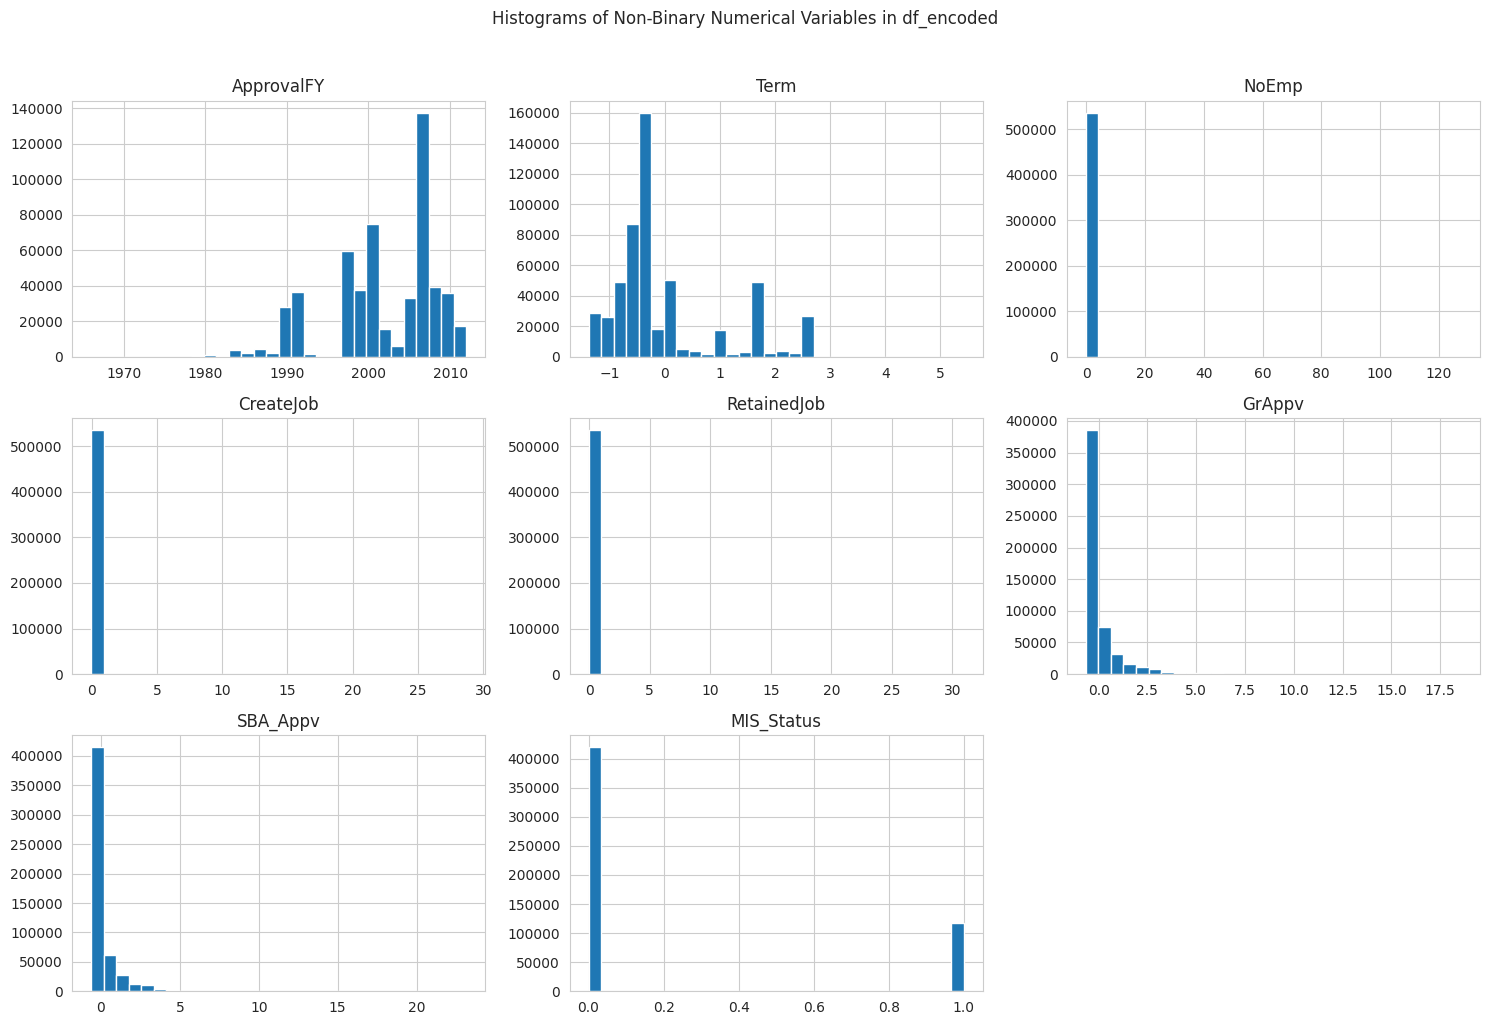

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Identify non-binary numerical columns in df_encoded to look at their distributions as well as our target variable to see how balanced or unbalanced our dataset is
non_binary_cols = [
    'ApprovalFY',
    'Term',
    'NoEmp',
    'CreateJob',
    'RetainedJob',
    'GrAppv',
    'SBA_Appv',
    'MIS_Status'
]
df_cleaned[non_binary_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle('Histograms of Non-Binary Numerical Variables in df_encoded', y=1.02)
plt.tight_layout()
plt.show()

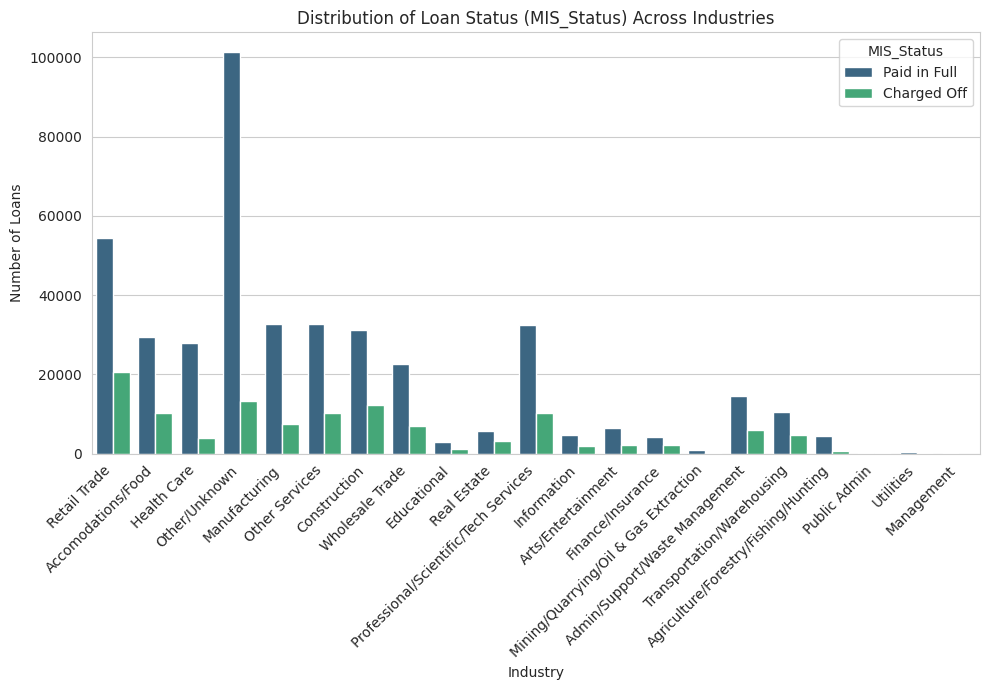

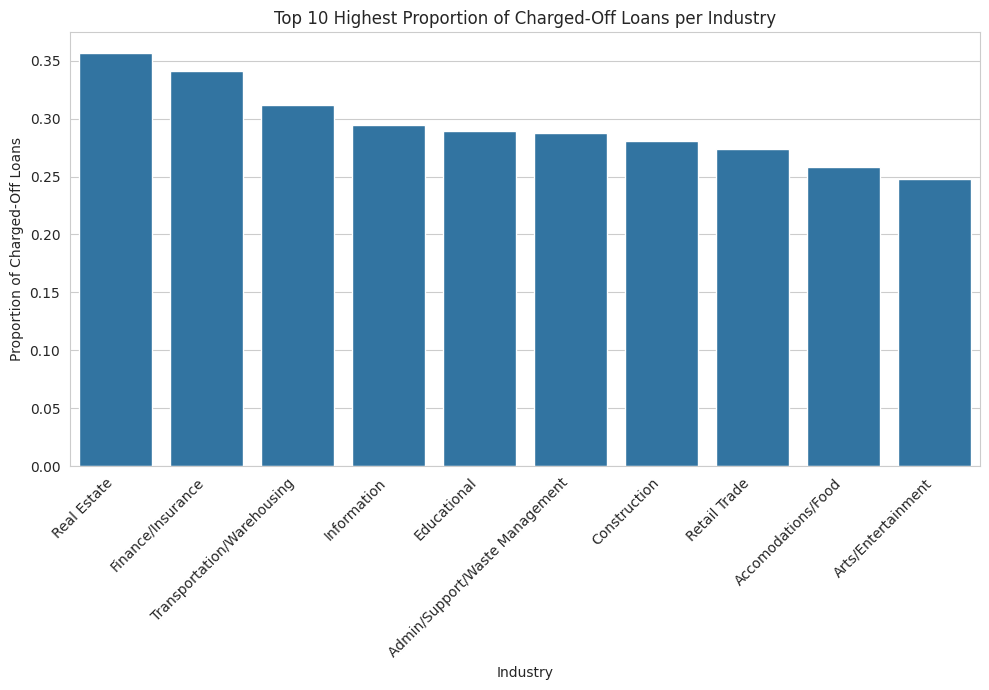

In [ ]:
sns.set_style("whitegrid")
# Plotting the distribution of MIS_Status across industries
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Industry', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status (MIS_Status) Across Industries')
plt.xlabel('Industry')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Optional: Calculate the proportion of charged-off loans per industry
industry_chargeoff_rate = df.groupby('Industry')['MIS_Status'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 7))
sns.barplot(x=industry_chargeoff_rate.index, y=industry_chargeoff_rate.values, legend=False)
plt.title('Top 10 Highest Proportion of Charged-Off Loans per Industry')
plt.xlabel('Industry')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
# Load the reference coordinate dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
city_coords = pd.read_csv(url)
# State Mapping (Standardizing for the merge)
state_map = {
    'AK': 'Alaska', 'AL': 'Alabama', 'AR': 'Arkansas', 'AZ': 'Arizona', 'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut',
    'DC': 'District of Columbia', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'IA': 'Iowa', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'MA': 'Massachusetts', 'MD': 'Maryland',
    'ME': 'Maine', 'MI': 'Michigan', 'MN': 'Minnesota', 'MO': 'Missouri', 'MS': 'Mississippi', 'MT': 'Montana', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'NE': 'Nebraska', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NV': 'Nevada',
    'NY': 'New York', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VA': 'Virginia', 'VT': 'Vermont', 'WA': 'Washington',
    'WI': 'Wisconsin', 'WV': 'West Virginia', 'WY': 'Wyoming'
}
# Clean and Aggregate Data
df['City_Clean'] = df['City'].astype(str).str.title()
df['State_Full'] = df['State'].map(state_map)

city_stats = df.groupby(['City_Clean', 'State_Full']).agg(
    total_loans=('MIS_Status', 'count'),
    charge_off_rate=('MIS_Status', 'mean')
).reset_index()
# Merge with coordinates
map_data = pd.merge(
    city_stats,
    city_coords[['City', 'State', 'lat', 'lon']],
    left_on=['City_Clean', 'State_Full'],
    right_on=['City', 'State'],
    how='inner'
)
# Filter out cities with fewer than 30 loans to stabilize the "Percent Default"
min_volume_threshold = 30
trusted_map_data = map_data[map_data['total_loans'] >= min_volume_threshold]
# Create the Map
fig = px.scatter_geo(
    trusted_map_data.nlargest(500, 'total_loans'), # Increased to 500 cities for better coverage
    lat='lat',
    lon='lon',
    hover_name="City_Clean",
    # Adding total_loans to hover so the user can see the sample size
    hover_data={
        'lat': False,
        'lon': False,
        'total_loans': ':,',
        'charge_off_rate': ':.2%'
    },
    size="total_loans",
    color="charge_off_rate",
    scope="usa",
    template="plotly_white",
    color_continuous_scale="RdYlGn_r", # Red (High Risk) to Green (Low Risk)
    title=f'SBA Loan Risk Map (Cities with >{min_volume_threshold} Loans)',
    labels={'charge_off_rate': 'Default Rate', 'total_loans': 'Volume (Total Loans)'}
)
fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    height=700,
    geo=dict(
        landcolor="rgb(240, 240, 240)",
        lakecolor="white",
        showlakes=True
    )
)
fig.show()

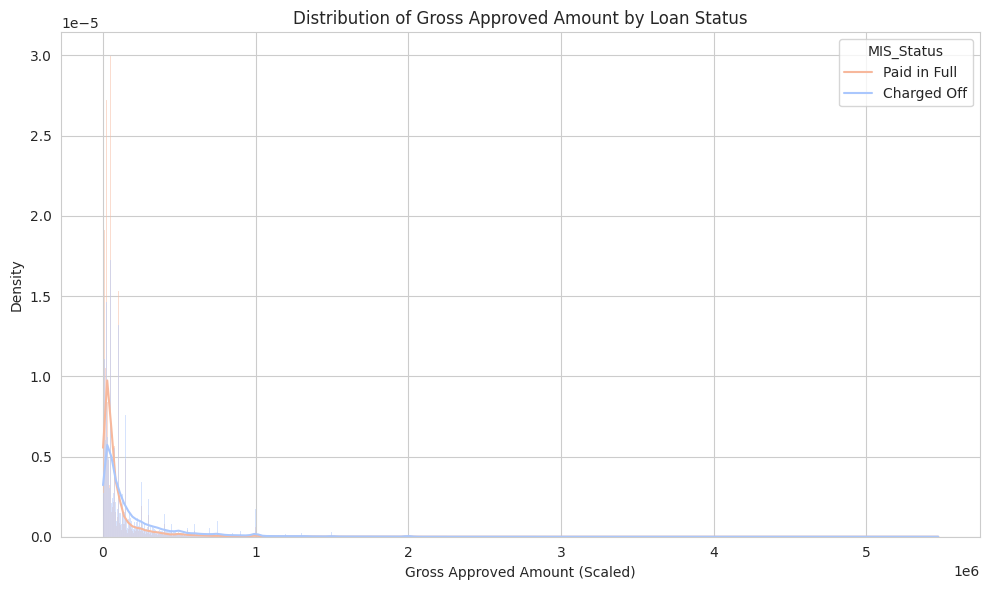

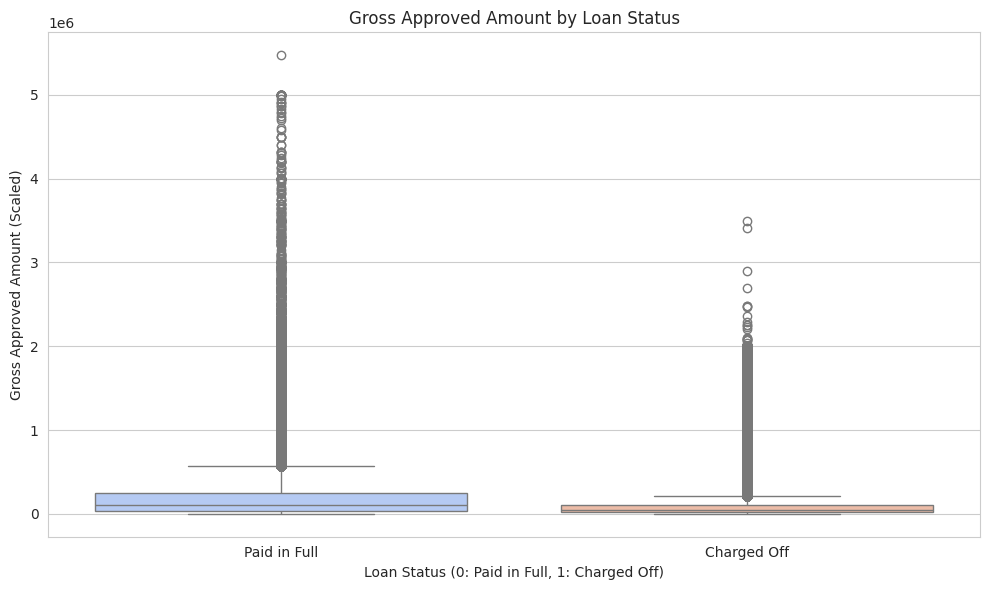

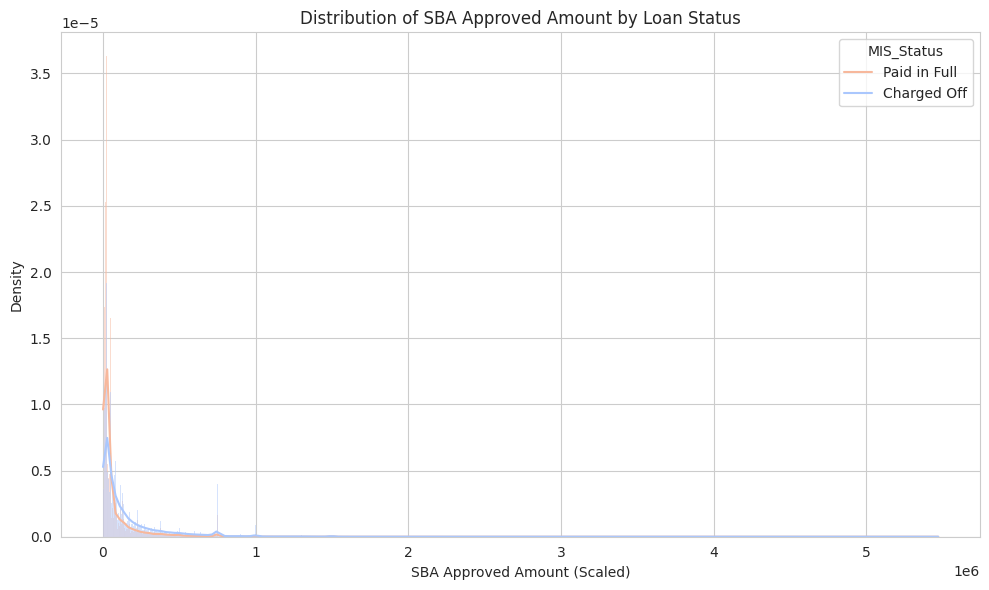

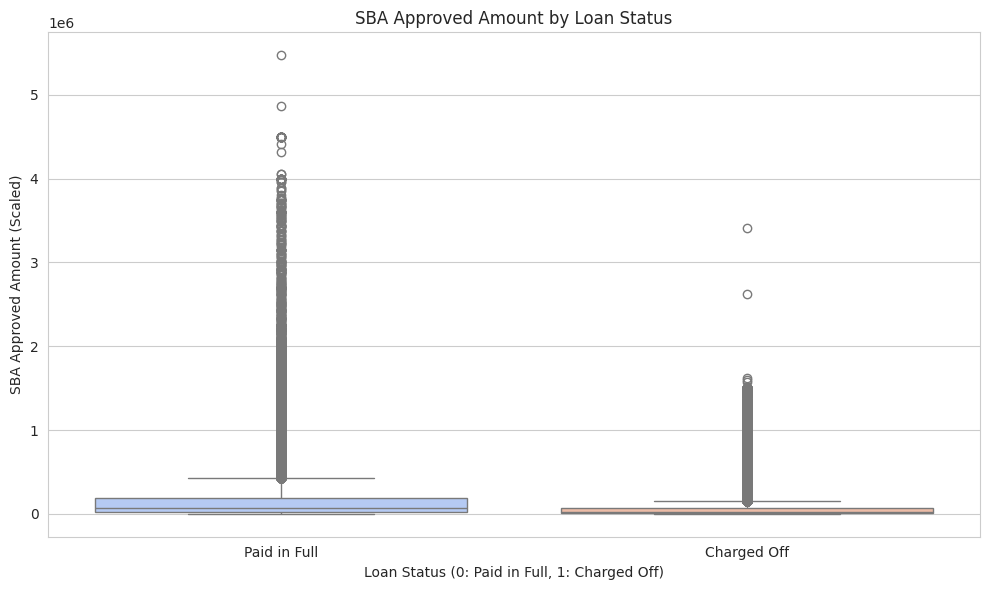

In [ ]:
sns.set_style("whitegrid")
# Distribution of Gross Approved Amount (GrAppv) by MIS_Status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='GrAppv', hue='MIS_Status', kde=True, palette='coolwarm', stat='density', common_norm=False)
plt.title('Distribution of Gross Approved Amount by Loan Status')
plt.xlabel('Gross Approved Amount (Scaled)')
plt.ylabel('Density')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Box plot of Gross Approved Amount (GrAppv) by MIS_Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MIS_Status', y='GrAppv', hue='MIS_Status', palette='coolwarm', legend=False)
plt.title('Gross Approved Amount by Loan Status')
plt.xlabel('Loan Status (0: Paid in Full, 1: Charged Off)')
plt.ylabel('Gross Approved Amount (Scaled)')
plt.xticks([0, 1], ['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Now for SBA_Appv (SBA Approved amount)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='SBA_Appv', hue='MIS_Status', kde=True, palette='coolwarm', stat='density', common_norm=False)
plt.title('Distribution of SBA Approved Amount by Loan Status')
plt.xlabel('SBA Approved Amount (Scaled)')
plt.ylabel('Density')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MIS_Status', y='SBA_Appv', hue='MIS_Status', palette='coolwarm', legend=False)
plt.title('SBA Approved Amount by Loan Status')
plt.xlabel('Loan Status (0: Paid in Full, 1: Charged Off)')
plt.ylabel('SBA Approved Amount (Scaled)')
plt.xticks([0, 1], ['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()

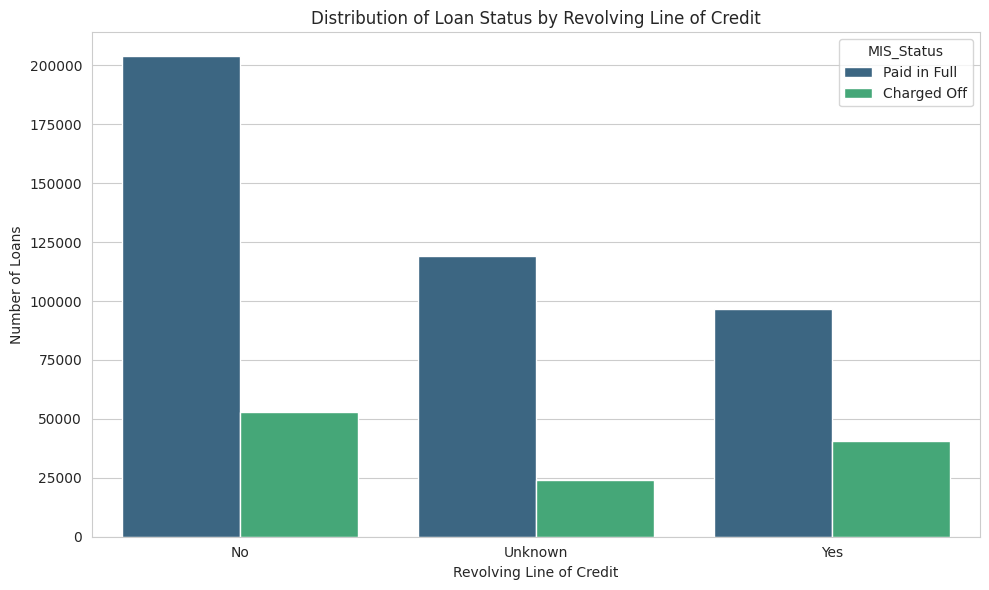

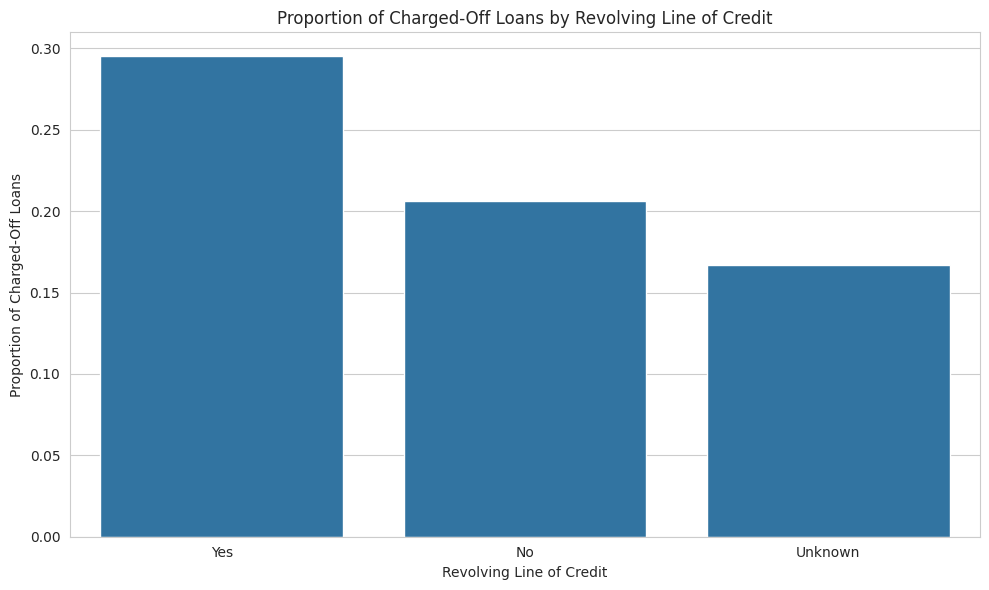

In [ ]:
sns.set_style("whitegrid")
# Plotting the distribution of MIS_Status across RevLineCr categories
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='RevLineCr', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by Revolving Line of Credit')
plt.xlabel('Revolving Line of Credit')
plt.ylabel('Number of Loans')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans per RevLineCr category
revlinecr_chargeoff_rate = df.groupby('RevLineCr')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=revlinecr_chargeoff_rate.index, y=revlinecr_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by Revolving Line of Credit')
plt.xlabel('Revolving Line of Credit')
plt.ylabel('Proportion of Charged-Off Loans')
plt.tight_layout()
plt.show()

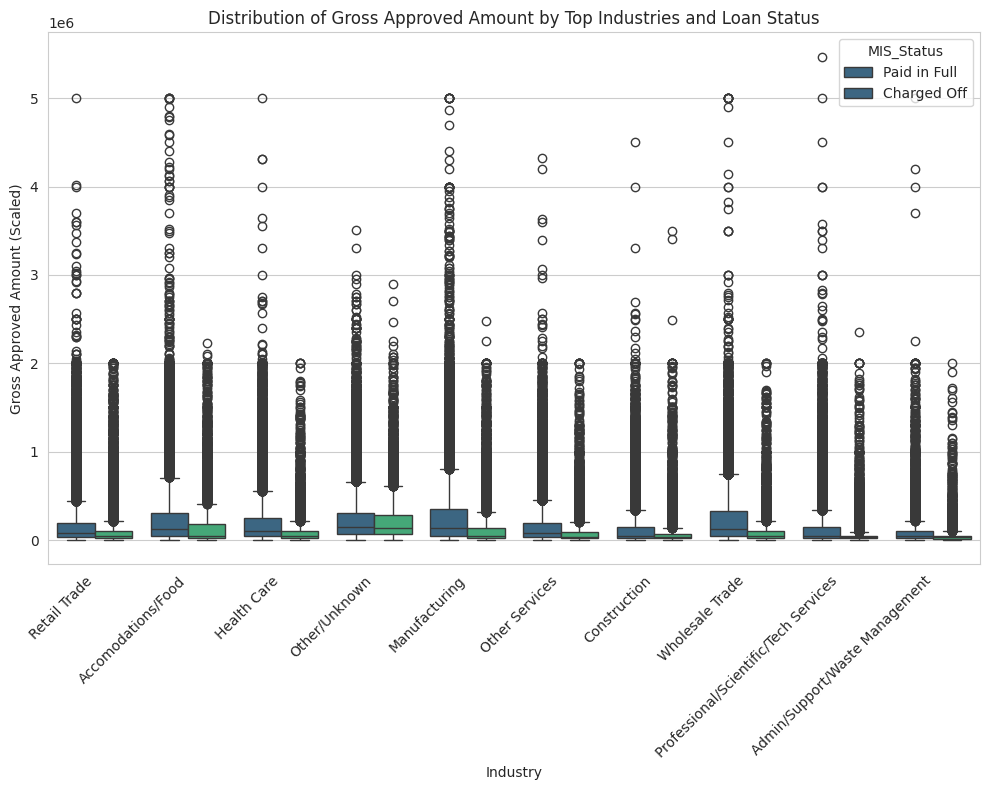

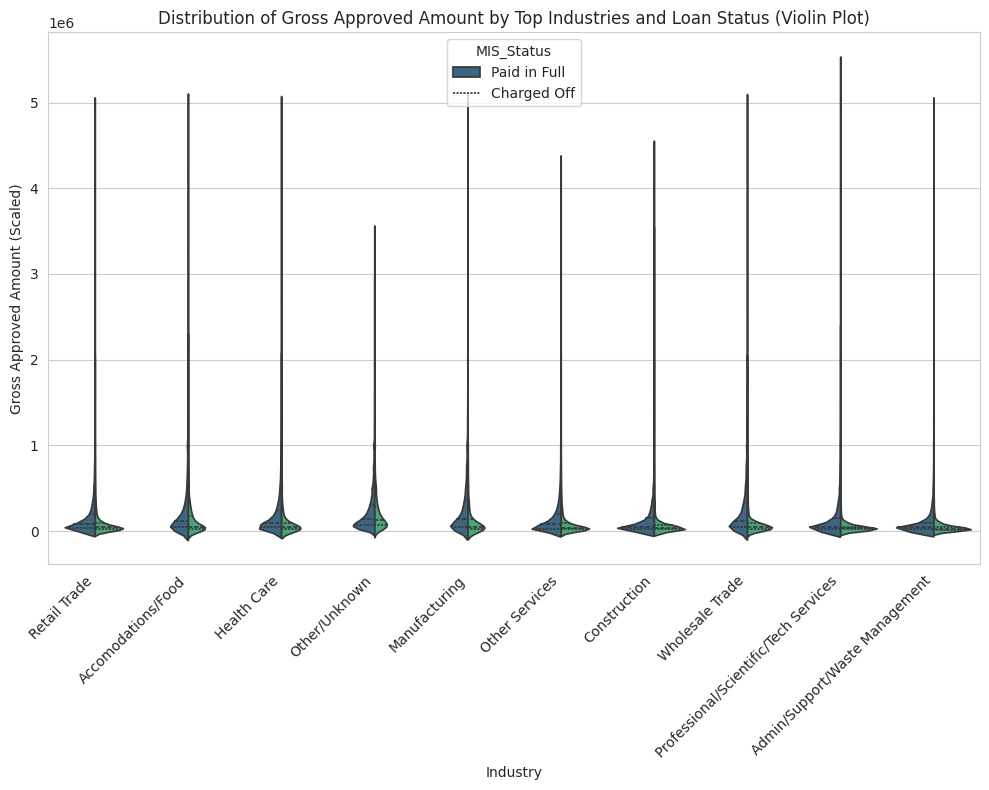

In [ ]:
sns.set_style("whitegrid")
# Select top N industries by count for better visualization
top_n_industries = df['Industry'].value_counts().head(10).index
df_top_industries = df[df['Industry'].isin(top_n_industries)]
# Box plot of Gross Approved Amount (GrAppv) by Industry, with MIS_Status as hue
plt.figure(figsize=(10, 8))
sns.boxplot(data=df_top_industries, x='Industry', y='GrAppv', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Gross Approved Amount by Top Industries and Loan Status')
plt.xlabel('Industry')
plt.ylabel('Gross Approved Amount (Scaled)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Alternative: Violin plot for a richer view of distribution
plt.figure(figsize=(10, 8))
sns.violinplot(data=df_top_industries, x='Industry', y='GrAppv', hue='MIS_Status', split=True, inner='quart', palette='viridis')
plt.title('Distribution of Gross Approved Amount by Top Industries and Loan Status (Violin Plot)')
plt.xlabel('Industry')
plt.ylabel('Gross Approved Amount (Scaled)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()

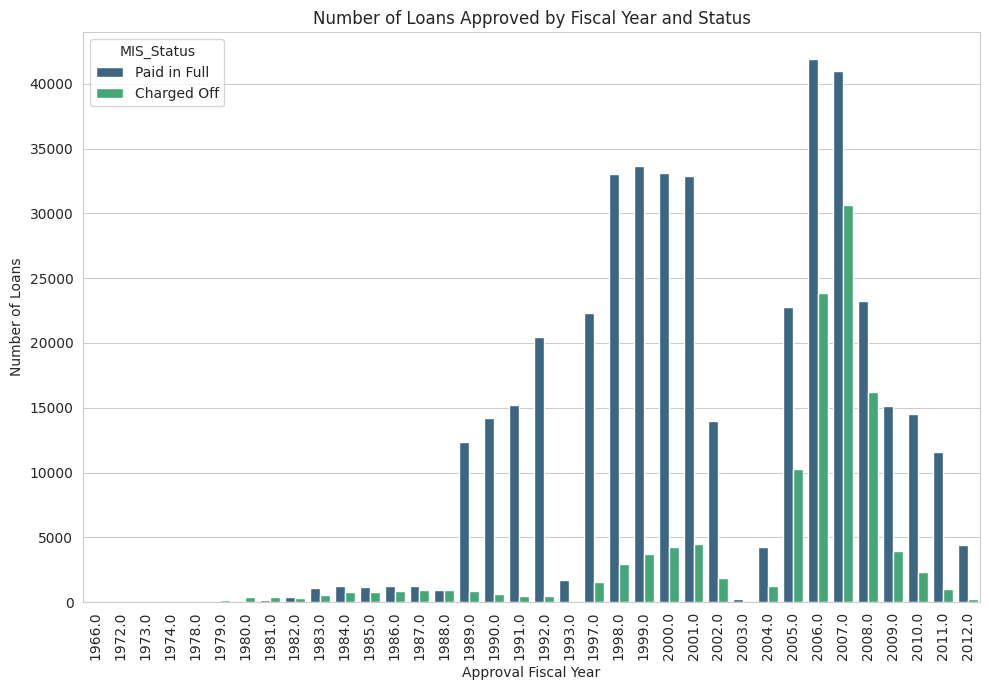

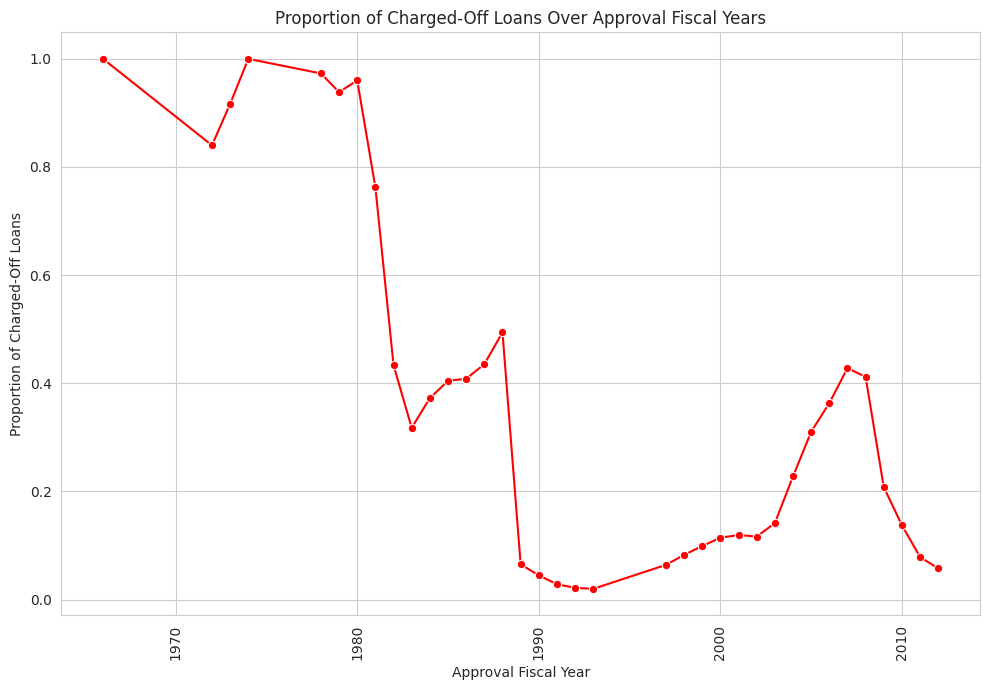

In [ ]:
sns.set_style("whitegrid")
# Plotting the count of loans by ApprovalFY and MIS_Status
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='ApprovalFY', hue='MIS_Status', palette='viridis')
plt.title('Number of Loans Approved by Fiscal Year and Status')
plt.xlabel('Approval Fiscal Year')
plt.ylabel('Number of Loans')
plt.xticks(rotation=90)
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans per ApprovalFY
fy_chargeoff_rate = df.groupby('ApprovalFY')['MIS_Status'].mean()
plt.figure(figsize=(10, 7))
sns.lineplot(x=fy_chargeoff_rate.index, y=fy_chargeoff_rate.values, marker='o', color='red')
plt.title('Proportion of Charged-Off Loans Over Approval Fiscal Years')
plt.xlabel('Approval Fiscal Year')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

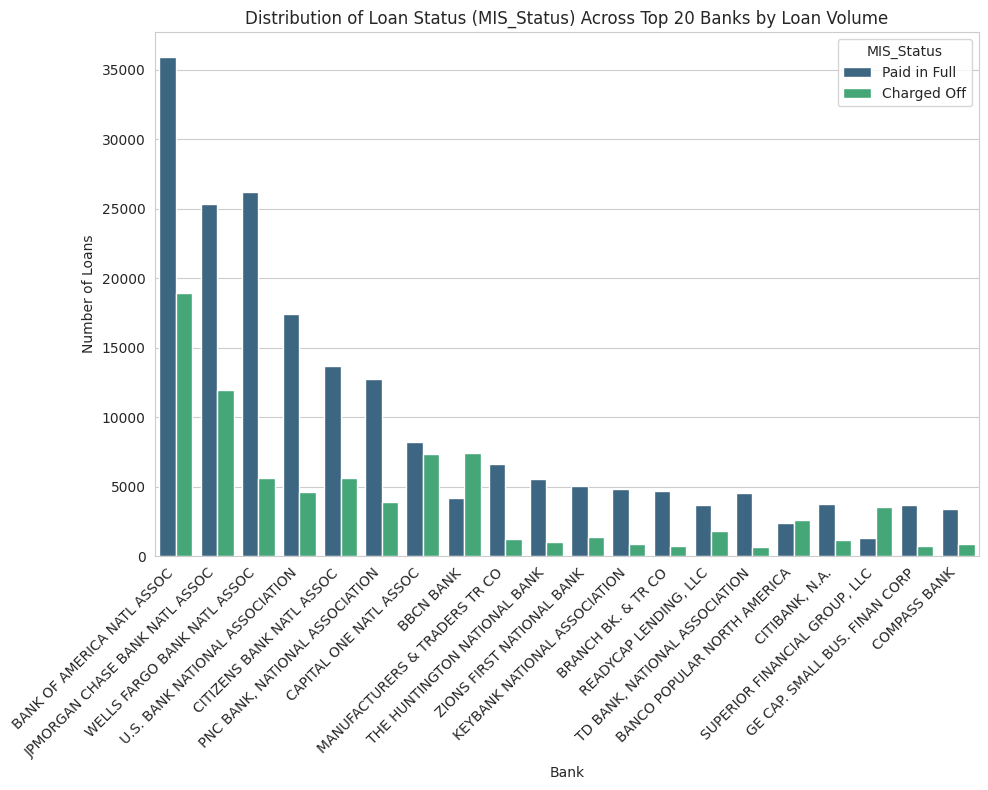

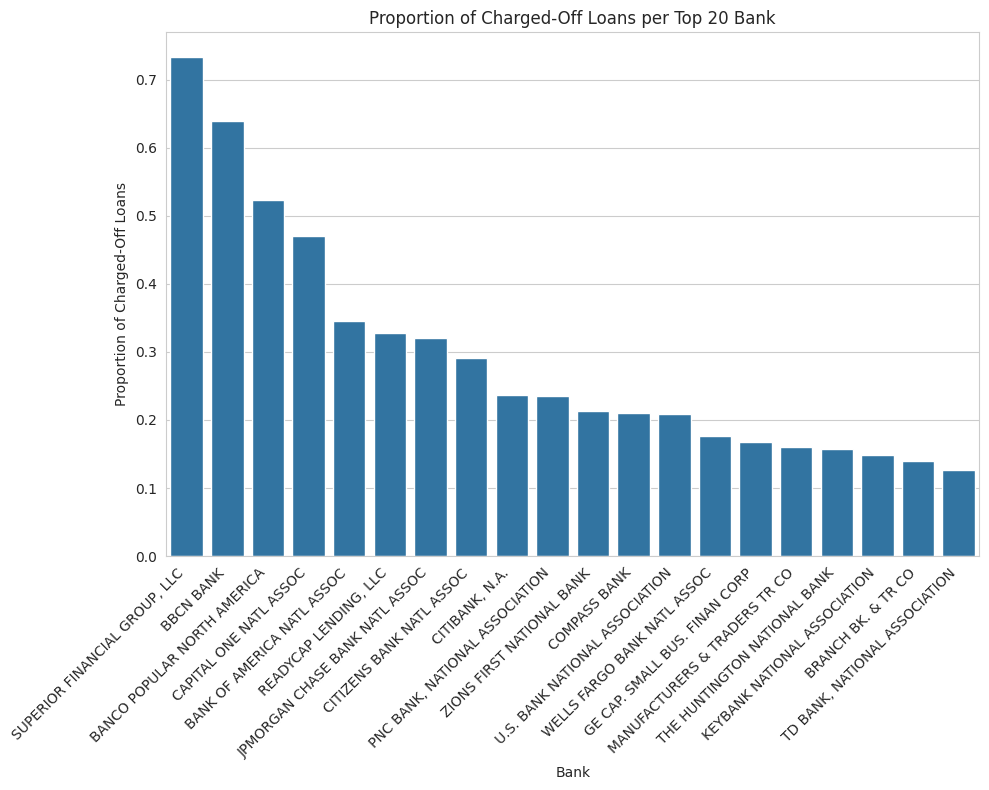

In [ ]:
sns.set_style("whitegrid")
# Calculate loan counts per bank
bank_loan_counts = df['Bank'].value_counts()
# Select the top N banks (e.g., top 20) for better visualization
top_n = 20
top_banks = bank_loan_counts.head(top_n).index
# Filter the DataFrame to include only these top banks
df_top_banks = df[df['Bank'].isin(top_banks)]
# Plotting the distribution of MIS_Status across top banks
plt.figure(figsize=(10, 8))
sns.countplot(data=df_top_banks, x='Bank', hue='MIS_Status', palette='viridis', order=top_banks)
plt.title(f'Distribution of Loan Status (MIS_Status) Across Top {top_n} Banks by Loan Volume')
plt.xlabel('Bank')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans for these top banks
bank_chargeoff_rate = df_top_banks.groupby('Bank')['MIS_Status'].mean().loc[top_banks].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=bank_chargeoff_rate.index, y=bank_chargeoff_rate.values, legend=False)
plt.title(f'Proportion of Charged-Off Loans per Top {top_n} Bank')
plt.xlabel('Bank')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

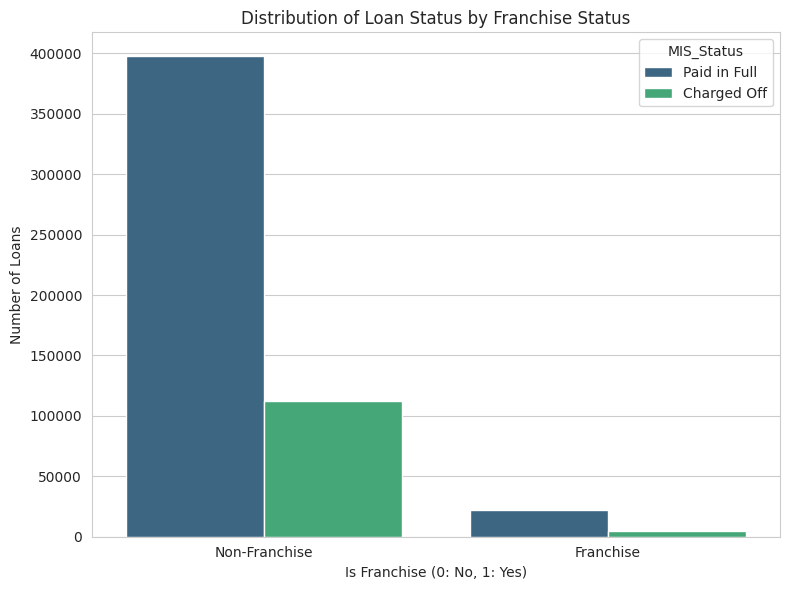

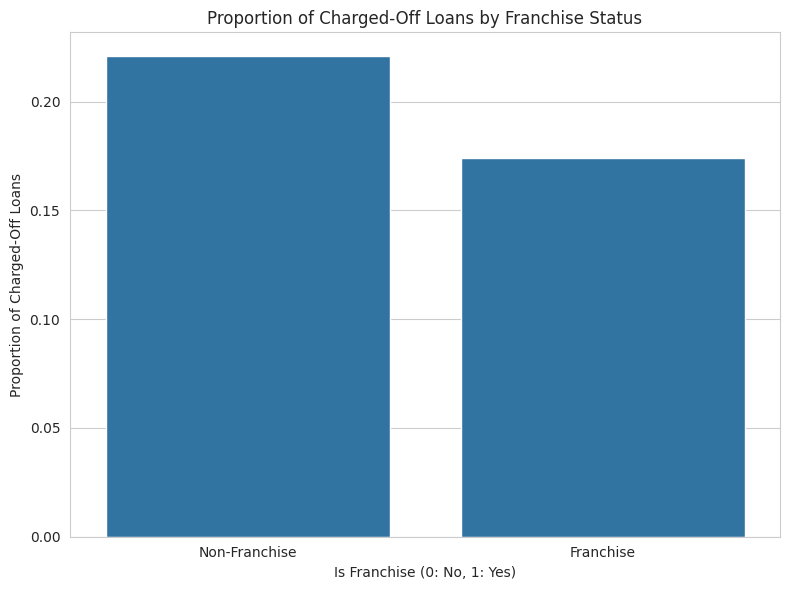

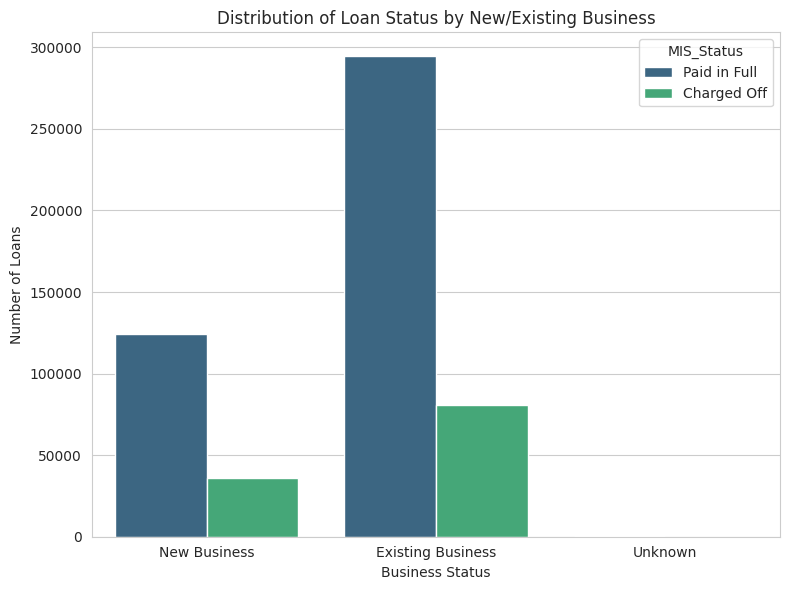

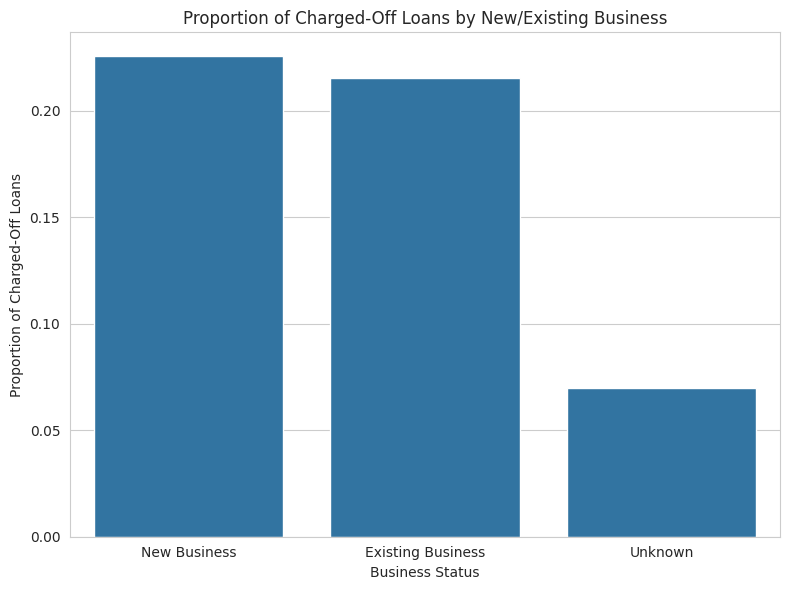

In [ ]:
sns.set_style("whitegrid")
# --- EDA for IsFranchise vs MIS_Status ---
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='IsFranchise', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by Franchise Status')
plt.xlabel('Is Franchise (0: No, 1: Yes)')
plt.ylabel('Number of Loans')
plt.xticks([0, 1], ['Non-Franchise', 'Franchise'])
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
franchise_chargeoff_rate = df.groupby('IsFranchise')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=franchise_chargeoff_rate.index, y=franchise_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by Franchise Status')
plt.xlabel('Is Franchise (0: No, 1: Yes)')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks([0, 1], ['Non-Franchise', 'Franchise'])
plt.tight_layout()
plt.show()
# --- EDA for NewExist vs MIS_Status ---
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='NewExist', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by New/Existing Business')
plt.xlabel('Business Status')
plt.ylabel('Number of Loans')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
newexist_chargeoff_rate = df.groupby('NewExist')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=newexist_chargeoff_rate.index, y=newexist_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by New/Existing Business')
plt.xlabel('Business Status')
plt.ylabel('Proportion of Charged-Off Loans')
plt.tight_layout()
plt.show()

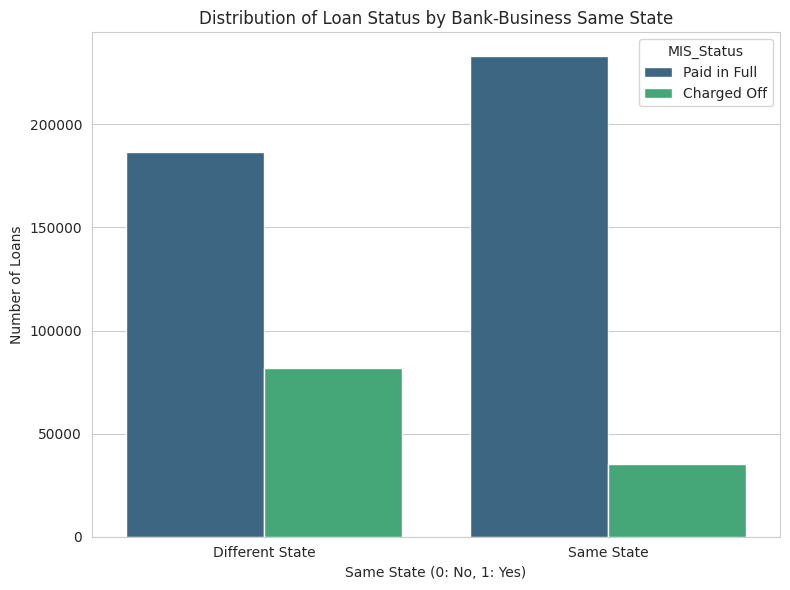

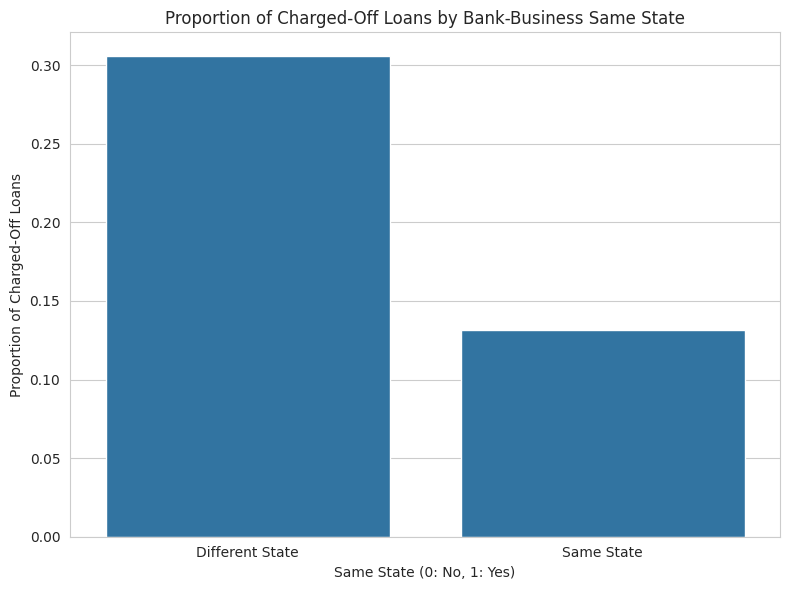

In [ ]:
sns.set_style("whitegrid")
# Create a new feature: Is the bank in the same state as the business?
df['SameState'] = (df['State'] == df['BankState']).astype(int)
# Plotting the distribution of MIS_Status by SameState
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='SameState', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by Bank-Business Same State')
plt.xlabel('Same State (0: No, 1: Yes)')
plt.ylabel('Number of Loans')
plt.xticks([0, 1], ['Different State', 'Same State'])
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans by SameState
same_state_chargeoff_rate = df.groupby('SameState')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=same_state_chargeoff_rate.index, y=same_state_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by Bank-Business Same State')
plt.xlabel('Same State (0: No, 1: Yes)')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks([0, 1], ['Different State', 'Same State'])
plt.tight_layout()
plt.show()

# Machine Learning

In [ ]:
import pandas as pd
import numpy as np
df_cleaned = pd.read_csv('SBAnational_cleaned.csv')
df_cleaned.head(5)

,City,State,Zip,Bank,BankState,ApprovalFY,MIS_Status,IsFranchise,Term,NoEmp,...,Industry_Mining/Quarrying/Oil & Gas Extraction,Industry_Other Services,Industry_Other/Unknown,Industry_Professional/Scientific/Tech Services,Industry_Public Admin,Industry_Real Estate,Industry_Retail Trade,Industry_Transportation/Warehousing,Industry_Utilities,Industry_Wholesale Trade
0,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,1997,0.0,0,-0.095118,-0.070299,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,1997,0.0,0,-0.455065,-0.100950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,1997,0.0,0,1.344670,-0.024324,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,1997,0.0,0,-0.455065,-0.100950,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,1997,0.0,0,2.244538,0.082953,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
# --- 1. Features and Target Declaration ---
y = df_cleaned['MIS_Status']
X = df_cleaned.drop(columns=['MIS_Status', 'City', 'State', 'Zip', 'Bank', 'BankState'], errors='ignore')
# --- 2. Initial Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# --- 3. Model Initializations ---
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}
# --- 4. K-Fold Configuration ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# --- 5. Model Comparison Loop using F1-Score ---
print(f"{'Model':<20} | {'Mean F1-Score':<15} | {'Std Dev':<10}")
print("-" * 50)
cv_results = {}
for name, model in models.items():
    # Use scoring='f1' to optimize for the balance between precision and recall
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    mean_f1 = scores.mean()
    std_f1 = scores.std()
    cv_results[name] = mean_f1
    print(f"{name:<20} | {mean_f1:<15.4f} | {std_f1:<10.4f}")
# --- 6. Final Evaluation of the Best Model ---
best_model_name = max(cv_results, key=cv_results.get)
print(f"\nBest Model by F1-Score: {best_model_name}")
# Train the winner on the full training set
final_model = models[best_model_name]
final_model.fit(X_train, y_train)
# Predict on the hold-out test set
y_pred = final_model.predict(X_test)
# Detailed Report
print(f"\nFinal Performance Report for {best_model_name}:")
print(classification_report(y_test, y_pred))

Model                | Mean F1-Score   | Std Dev   
--------------------------------------------------
Random Forest        | 0.8575          | 0.0027    
Logistic Regression  | 0.6990          | 0.0068    
XGBoost              | 0.8904          | 0.0054    
Decision Tree        | 0.8250          | 0.0024    
KNN                  | 0.7438          | 0.0074    

Best Model by F1-Score: XGBoost

Final Performance Report for XGBoost:
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96     10960
         1.0       0.89      0.88      0.88      3441

    accuracy                           0.95     14401
   macro avg       0.93      0.92      0.92     14401
weighted avg       0.95      0.95      0.95     14401



In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# 1. Create a stratified sample for tuning (using a percentage to avoid size errors)
# Since your X_train has 53,548 rows, train_size=0.8 will use ~42,838 rows for tuning.
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=0.8, stratify=y_train, random_state=42
)

# 2. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1, 5]
}

# 3. Initialize RandomizedSearch
# Clean initialization without deprecated parameters
xgb_tune = XGBClassifier(eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_grid,
    n_iter=10,           # Tries 10 random combinations
    scoring='f1',        # Optimizing for the imbalanced class
    cv=3,                # 3-fold cross-validation
    verbose=2,
    n_jobs=-1,           # Uses all available CPU cores
    random_state=42
)

# 4. Run the tuning
print(f"Starting Hyperparameter Tuning on {len(X_tune)} rows...")
random_search.fit(X_tune, y_tune)

# 5. Extract the best model and parameters
print(f"\nBest Parameters found: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

# 6. Final Evaluation on the full Hold-out Test Set
# Important: We retrain the best version on the ENTIRE X_train (53,548 rows)
print("Retraining best model on full training set...")
best_xgb.fit(X_train, y_train)
y_pred_final = best_xgb.predict(X_test)

print("\n--- Final Performance Report (Tuned XGBoost) ---")
print(classification_report(y_test, y_pred_final))

Starting Hyperparameter Tuning on 46080 rows...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters found: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 1, 'colsample_bytree': 1.0}
Retraining best model on full training set...

--- Final Performance Report (Tuned XGBoost) ---
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96     10960
         1.0       0.89      0.88      0.88      3441

    accuracy                           0.95     14401
   macro avg       0.93      0.92      0.92     14401
weighted avg       0.95      0.95      0.95     14401



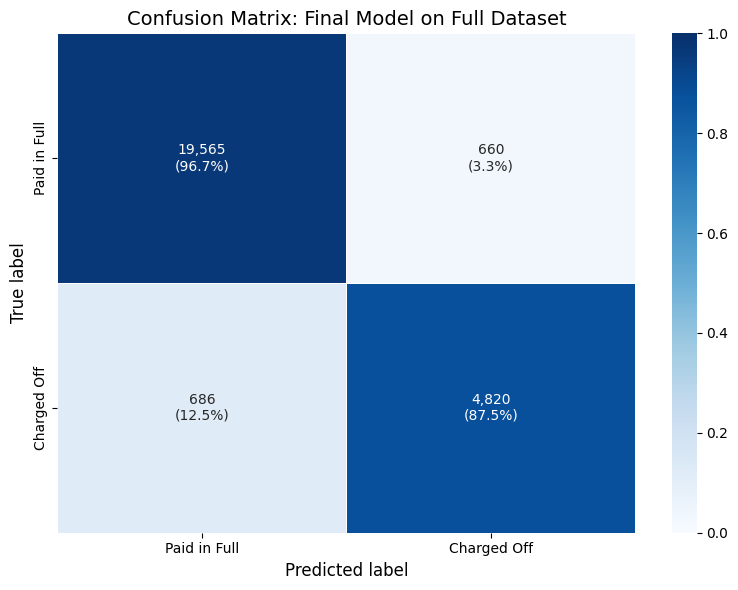

              precision    recall  f1-score   support

Paid in Full       0.97      0.97      0.97     20225
 Charged Off       0.88      0.88      0.88      5506

    accuracy                           0.95     25731
   macro avg       0.92      0.92      0.92     25731
weighted avg       0.95      0.95      0.95     25731



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Define and train the final model on the training set
final_model = XGBClassifier(
    eval_metric='logloss',
    subsample=0.8,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    gamma=5,
    colsample_bytree=0.8,
    random_state=42
)
final_model.fit(X_train, y_train)

# 2. Predict on ALL data (full X, not just test set)
y_pred_all = final_model.predict(X)

# 3. Build confusion matrix against all true labels
cm = confusion_matrix(y, y_pred_all)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = ['Paid in Full', 'Charged Off']
annot = np.array([
    [f"{cm[i,j]:,}\n({cm_norm[i,j]:.1%})" for j in range(2)]
    for i in range(2)
])

# 4. Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix: Final Model on Full Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# 5. Full classification report
print(classification_report(y, y_pred_all, target_names=labels))

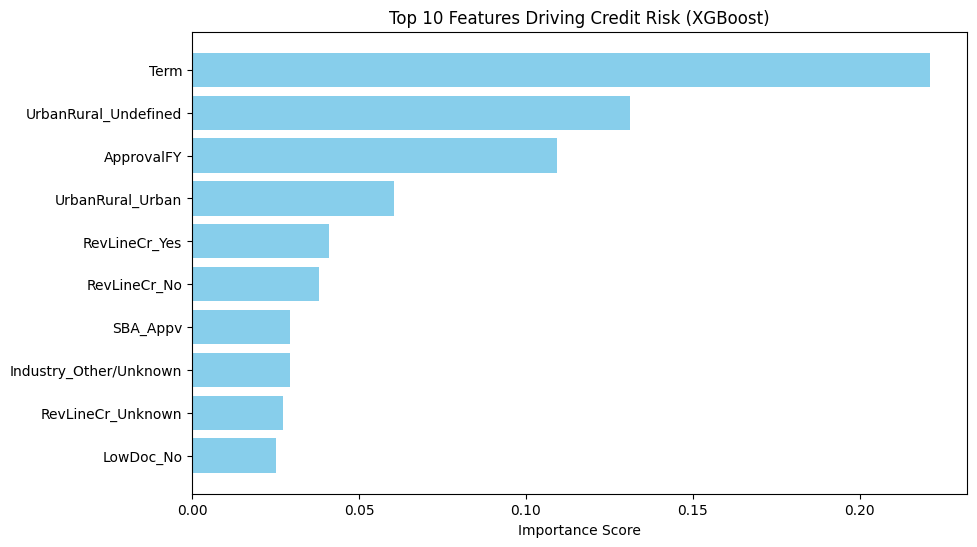

                   Feature  Importance
2                     Term    0.221136
12    UrbanRural_Undefined    0.131196
0               ApprovalFY    0.109475
13        UrbanRural_Urban    0.060501
16           RevLineCr_Yes    0.041163
14            RevLineCr_No    0.037887
7                 SBA_Appv    0.029471
33  Industry_Other/Unknown    0.029421
15       RevLineCr_Unknown    0.027222
17               LowDoc_No    0.024989


In [ ]:
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
# Based on best parameters found above, create final xgboost model
final_model = XGBClassifier(eval_metric='logloss',
                                    subsample = 0.8,
                                    n_estimators = 100,
                                    max_depth = 6,
                                    learning_rate = 0.1,
                                    gamma = 5,
                                    colsample_bytree = 0.8,
                                    random_state = 42)
# Fit model
final_model.fit(X_train, y_train)  # ← ADD THIS LINE
y_pred_final = final_model.predict(X_test)
# Get feature importance from the model
importances = final_model.feature_importances_
feature_names = X_train.columns
# Create a DataFrame for easy sorting and plotting
feature_insight = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_insight = feature_insight.sort_values(by='Importance', ascending=False)
# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_insight['Feature'].head(10), feature_insight['Importance'].head(10), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features Driving Credit Risk (XGBoost)')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()
# Print the table
print(feature_insight.head(10))

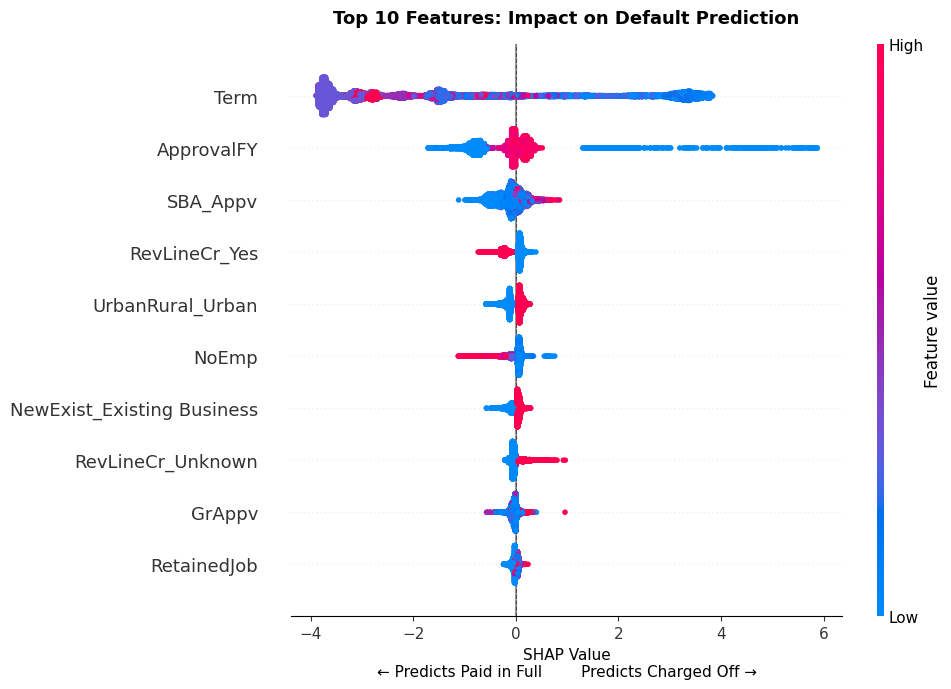

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Get SHAP values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# 2. Find top 10 features by mean absolute SHAP value
top10_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
top10_features = X_test.columns[top10_idx]

# 3. Filter SHAP values and data to top 10 only
shap_top10 = shap_values[:, top10_idx]
X_top10 = X_test[top10_features]

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_top10,
    X_top10,
    plot_type="dot",
    plot_size=None,     # disables auto-resizing so our figsize applies
    show=False
)

ax = plt.gca()
ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=11)
ax.set_title("Top 10 Features: Impact on Default Prediction", fontsize=13, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

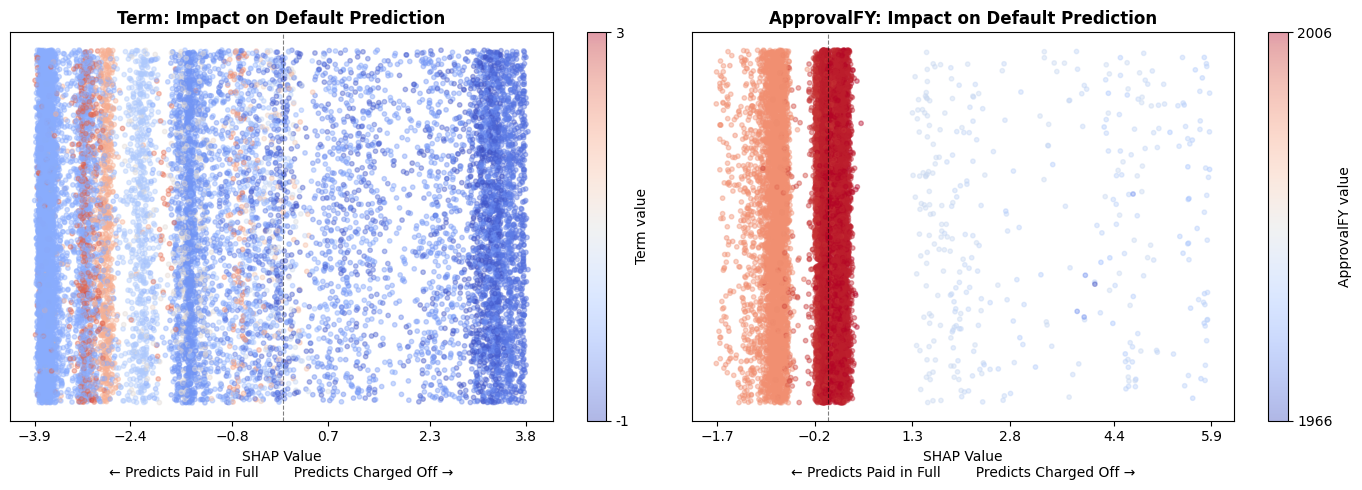

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, ['Term', 'ApprovalFY']):
    feat_idx = X_test.columns.get_loc(feature)
    shap_feat = shap_values[:, feat_idx]
    feat_vals = X_test[feature].values

    scatter = ax.scatter(
        shap_feat,
        np.random.uniform(-0.3, 0.3, size=len(shap_feat)),  # jitter on y-axis
        c=feat_vals,
        cmap='coolwarm',
        alpha=0.4,
        s=10
    )

    # Colorbar showing actual feature values
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(f'{feature} value', fontsize=10)

    # Add actual min/max tick labels on colorbar
    cbar.set_ticks([feat_vals.min(), feat_vals.max()])
    cbar.set_ticklabels([f'{int(feat_vals.min())}', f'{int(feat_vals.max())}'])

    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_yticks([])
    ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=10)
    ax.set_title(f'{feature}: Impact on Default Prediction', fontsize=12, fontweight='bold')

    # Annotate min/max SHAP range on x-axis
    ax.set_xticks(np.round(np.linspace(shap_feat.min(), shap_feat.max(), 6), 1))

plt.tight_layout()
plt.show()

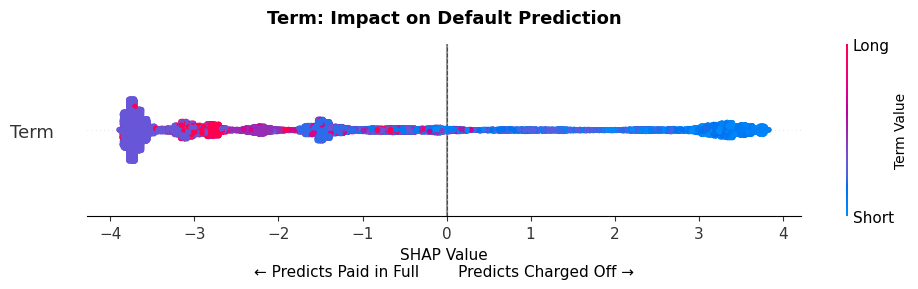

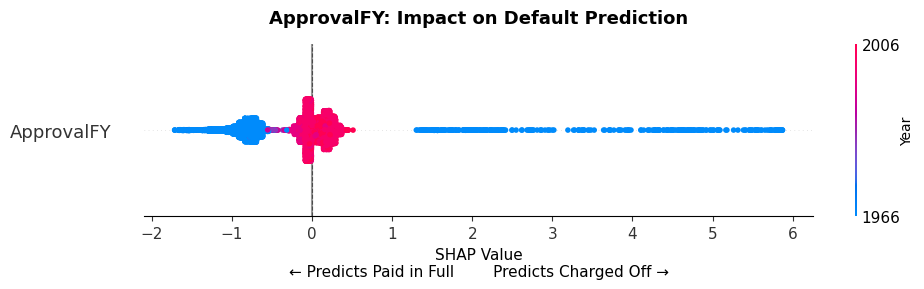

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Define friendly labels and min/max for each feature
feature_info = {
    'Term':       {'label': 'Term Value',    'min': 'Short', 'max': 'Long'},
    'ApprovalFY': {'label': 'Year',          'min': int(X_test['ApprovalFY'].min()), 'max': int(X_test['ApprovalFY'].max())}
}

for feature in ['Term', 'ApprovalFY']:
    feat_idx = X_test.columns.get_loc(feature)
    info = feature_info[feature]

    fig, ax = plt.subplots(figsize=(10, 3))
    shap.summary_plot(
        shap_values[:, feat_idx].reshape(-1, 1),
        X_test[[feature]],
        plot_type="dot",
        plot_size=None,
        show=False
    )

    ax = plt.gca()
    ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=11)
    ax.set_title(f'{feature}: Impact on Default Prediction', fontsize=13, fontweight='bold', pad=15)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Update colorbar with feature-specific label and min/max tick labels
    cbar_ax = plt.gcf().axes[-1]
    cbar_ax.set_ylabel(info['label'], fontsize=10)
    cbar_min, cbar_max = cbar_ax.get_ylim()
    cbar_ax.yaxis.set_ticks([cbar_min, cbar_max])
    cbar_ax.set_yticklabels([str(info['min']), str(info['max'])])

    plt.tight_layout()
    plt.show()

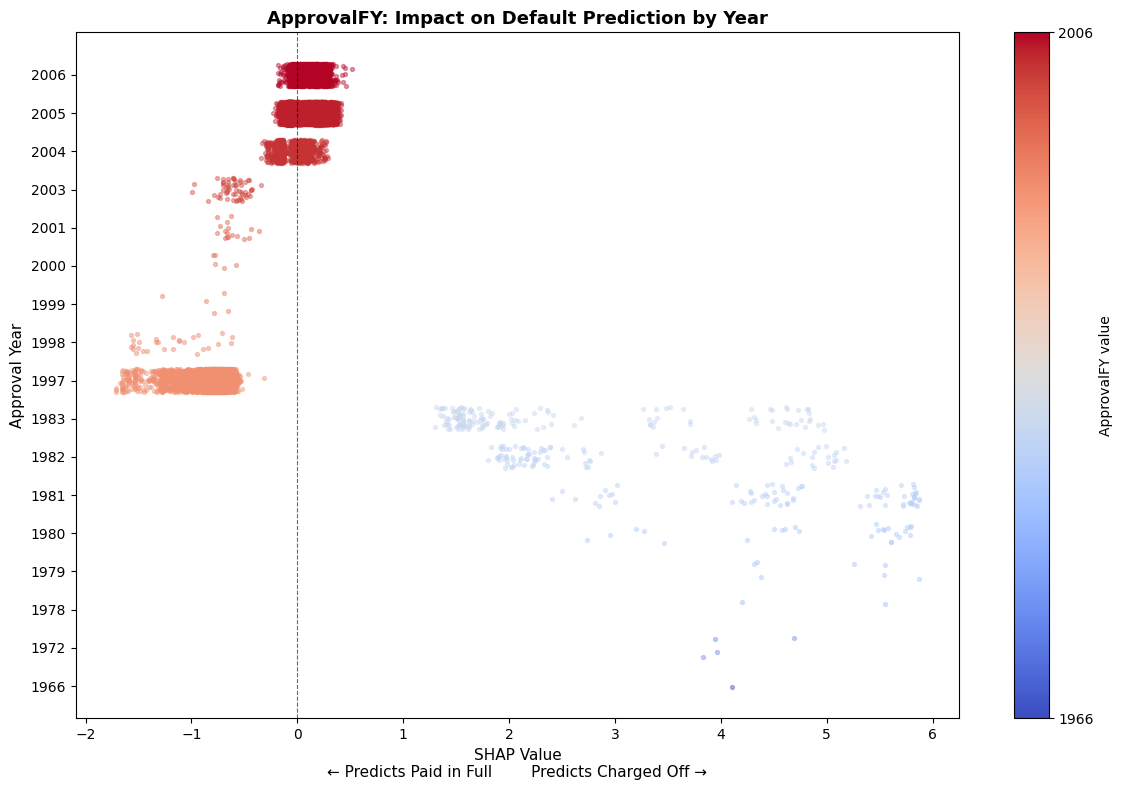

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

feat_idx = X_test.columns.get_loc('ApprovalFY')
shap_feat = shap_values[:, feat_idx]
feat_vals = X_test['ApprovalFY'].values

df_shap = pd.DataFrame({'shap': shap_feat, 'year': feat_vals})
years = sorted(df_shap['year'].unique())

# Normalize year values to 0-1 for colormap
norm = plt.Normalize(feat_vals.min(), feat_vals.max())
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(12, 8))

for i, year in enumerate(years):
    subset = df_shap[df_shap['year'] == year]['shap']
    y_jitter = np.random.uniform(i - 0.3, i + 0.3, size=len(subset))
    color = cmap(norm(year))  # color based on year value low=blue, high=red
    ax.scatter(subset, y_jitter, color=color, alpha=0.4, s=8)

# Add colorbar showing low/high year
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('ApprovalFY value', fontsize=10)
cbar.set_ticks([feat_vals.min(), feat_vals.max()])
cbar.set_ticklabels([str(int(feat_vals.min())), str(int(feat_vals.max()))])

ax.set_yticks(range(len(years)))
ax.set_yticklabels([str(int(y)) for y in years], fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=11)
ax.set_ylabel("Approval Year", fontsize=11)
ax.set_title("ApprovalFY: Impact on Default Prediction by Year", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

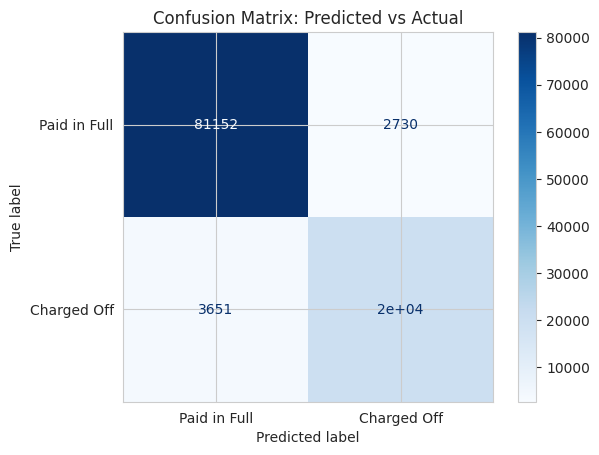

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
# Plot it
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Paid in Full', 'Charged Off'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # <-- this was missing

# Generate the matrix
cm = confusion_matrix(y, y_pred_final)  # change y_pred → y_pred_final
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-wise %

labels = ['Paid in Full', 'Charged Off']

# Build annotation text: "count\n(xx%)"
annot = np.array([
    [f"{cm[i,j]:,}\n({cm_norm[i,j]:.1%})" for j in range(2)]
    for i in range(2)
])

# Plot it
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm,          # color by row-normalized % so both rows are readable
    annot=annot,
    fmt='',           # using pre-formatted strings so no scientific notation
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1    # fix scale to 0–100%
)

ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix: Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [25731, 5147]

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, color='darkorange')
plt.title('Precision-Recall Curve')
plt.show()

NameError: name 'plt' is not defined

<Figure size 800x600 with 0 Axes>

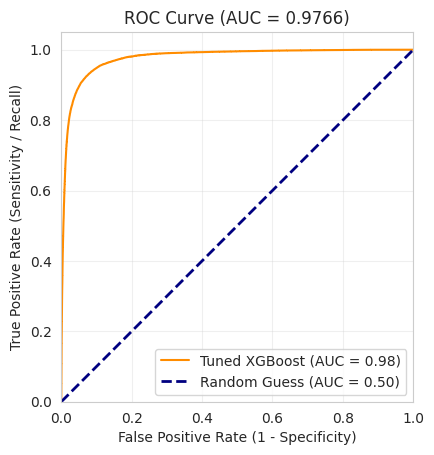

The Area Under the Curve (AUC) is: 0.9766


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# 1. Get the probability scores for the positive class (defaults)
# predict_proba returns [prob_class_0, prob_class_1]
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC-AUC score
auc_score = roc_auc_score(y_test, y_probs)

# 3. Plotting the ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_xgb, X_test, y_test, color='darkorange', name='Tuned XGBoost')

# Add the "Chance" line (diagonal) - what a random guesser would get
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title(f'ROC Curve (AUC = {auc_score:.4f})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"The Area Under the Curve (AUC) is: {auc_score:.4f}")

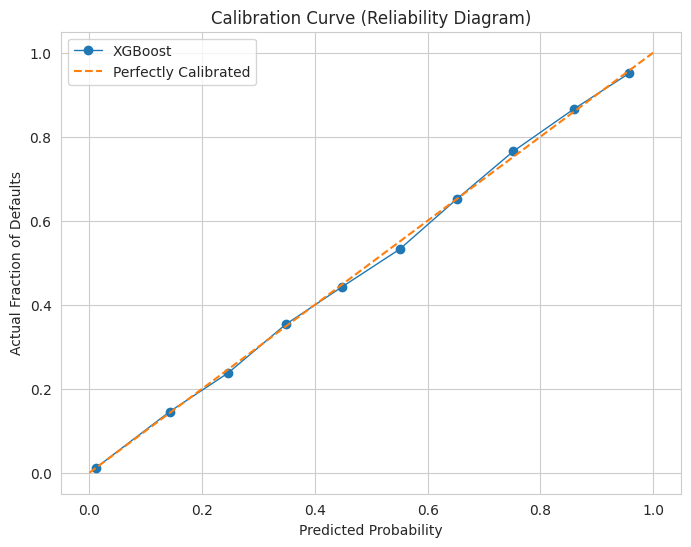

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get probabilities
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# Calculate calibration
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Fraction of Defaults')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.show()

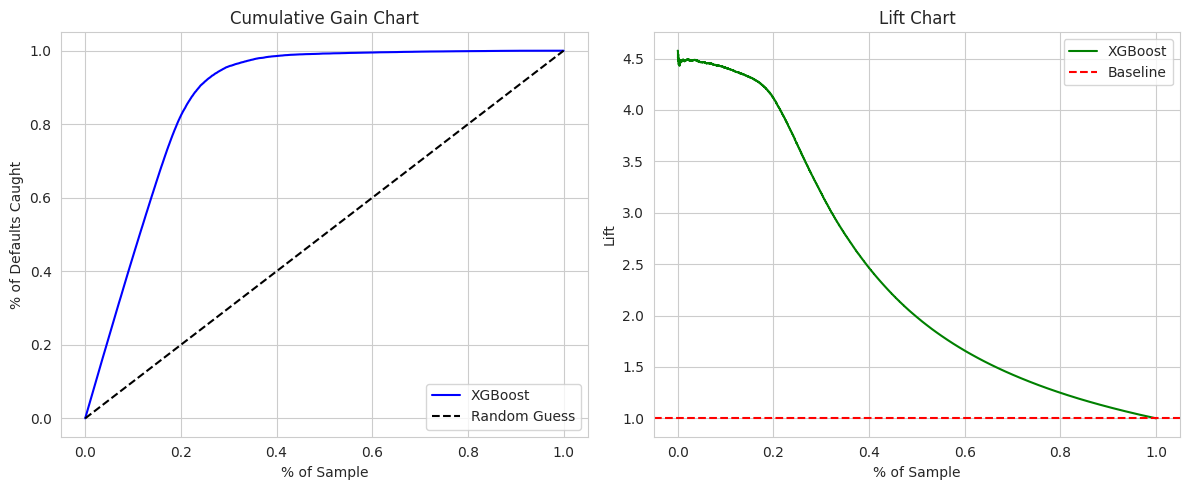

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_business_lift(y_true, y_probs):
    # Sort by probability descending
    data = pd.DataFrame({'actual': y_true, 'prob': y_probs}).sort_values('prob', ascending=False)
    data['cumulative_actual'] = data['actual'].cumsum()
    data['cumulative_all'] = np.arange(1, len(data) + 1)

    total_defaults = data['actual'].sum()

    # Gain: Percentage of total defaults caught
    data['gain'] = data['cumulative_actual'] / total_defaults
    # Lift: How much better than random
    data['lift'] = data['gain'] / (data['cumulative_all'] / len(data))

    plt.figure(figsize=(12, 5))

    # Plot Gain
    plt.subplot(1, 2, 1)
    plt.plot(np.linspace(0, 1, len(data)), data['gain'], label='XGBoost', color='blue')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.title('Cumulative Gain Chart')
    plt.xlabel('% of Sample')
    plt.ylabel('% of Defaults Caught')
    plt.legend()

    # Plot Lift
    plt.subplot(1, 2, 2)
    plt.plot(np.linspace(0, 1, len(data)), data['lift'], label='XGBoost', color='green')
    plt.axhline(1, color='red', linestyle='--', label='Baseline')
    plt.title('Lift Chart')
    plt.xlabel('% of Sample')
    plt.ylabel('Lift')
    plt.legend()
    plt.tight_layout()
    plt.show()

y_probs = best_xgb.predict_proba(X_test)[:, 1]
plot_business_lift(y_test, y_probs)

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer with your trained model
explainer = shap.TreeExplainer(final_model)

# 2. Calculate SHAP values on a sample of your test data
# Using a sample (e.g., 1000 rows) makes the calculation much faster
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# 3. Create the Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SBA Credit Loan Risk Analysis - Feature Importance (SHAP)")
plt.show()

In [ ]:
auc = roc_auc_score(y_test, y_probs)
gini = 2 * auc - 1
print(f"Gini Coefficient: {gini:.4f}")

Gini Coefficient: 0.9532


In [ ]:
from sklearn.metrics import brier_score_loss
score = brier_score_loss(y_test, y_probs)
print(f"Brier Score: {score:.4f}")

Brier Score: 0.0443


In [ ]:
from sklearn.metrics import confusion_matrix

def estimate_economic_value(y_true, y_pred, cost_of_default=100000, interest_lost=10000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Savings from catching defaults - Losses from missing good loans
    value = (tp * cost_of_default) - (fp * interest_lost)
    print(f"Estimated Model Value: ${value:,.2f}")
    print(f"Total Defaults Caught: {tp}")
    print(f"Good Loans Mistakenly Denied: {fp}")

# Run for your final XGBoost predictions
estimate_economic_value(y_test, y_pred_final)

Estimated Model Value: $92,470,000.00
Total Defaults Caught: 939
Good Loans Mistakenly Denied: 143


In [ ]:
# Create a 'Risk Score' column using your trained XGBoost model
# This allows Power BI to show risk levels for every loan
df_cleaned['Risk_Probability'] = final_model.predict_proba(X)[:, 1]

# Export to a CSV that Power BI can handle easily
df_cleaned.to_csv('SBA_PowerBI_Data.csv', index=False)